# IMDB Sentiment Analysis, MLP From Scratch (Gradient Descent)
Objective: is to build a Multi Layer Perceptron (MLP) trained from scratch using gradient descent to predict if an IMDB review is positive or negative.

Feature constraint: Only sentence-level polarity features are used (TextBlob polarity) and No word-level scoring, no padded vectors, no embeddings.


In [ ]:
# 1) Imports & configuration
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

DATA_PATH = r"../IMDB Dataset.csv"

# For quick tests you can set SAMPLE_SIZE to a smaller number (e.g., 10000).
# For final submission keep SAMPLE_SIZE = None to use ALL 50K reviews.
SAMPLE_SIZE = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# 2) Load dataset
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3) EDA (to check for : data types, distribution, missing values, duplicates)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(418)

In [7]:
# df = df.drop_duplicates().reset_index(drop=True)  # optional

## 4) Text preprocessing

In [8]:
def preprocess_text(text: str) -> str:
    t = str(text).lower()
    t = re.sub(r"<.*?>", " ", t)          # remove HTML tags
    t = re.sub(r"\s+", " ", t).strip()   # normalize whitespace
    return t

df["review_clean"] = df["review"].apply(preprocess_text)
df[["review", "review_clean"]].head()


,review,review_clean
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


## 5) Feature engineering (sentence-level polarity only)
Here We use TextBlob polarity (with a range of [-1, 1]) as the only input feature.

In [9]:
def textblob_polarity(text: str) -> float:
    return float(TextBlob(text).sentiment.polarity)

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df_work = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_work = df.copy()

df_work["polarity"] = df_work["review_clean"].apply(textblob_polarity)

X = df_work[["polarity"]].to_numpy(dtype=np.float64)  # (N,1)
y = df_work["sentiment"].map({"negative": 0, "positive": 1}).to_numpy(dtype=np.int64)  # (N,)

X.shape, y.shape, df_work["polarity"].describe()


((50000, 1),
 (50000,),
 count    50000.000000
 mean         0.102832
 std          0.163649
 min         -1.000000
 25%          0.003333
 50%          0.104016
 75%          0.203050
 max          1.000000
 Name: polarity, dtype: float64)

## 7) Train / Validation / Test split (70(T)/15(V)/15(TS))

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

X_train.shape, X_val.shape, X_test.shape


((35000, 1), (7500, 1), (7500, 1))

## 8) MLP from scratch (NumPy)
Architecture: 1 hidden layer (ReLU) + output layer (Sigmoid)

Loss: with binary Cross-Entropy

Training: Gradient Descent with manual parameter updates

In [11]:
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0.0).astype(np.float64)

def bce_loss(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def predict_proba(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = X @ W1 + b1        # (N,H)
    A1 = relu(Z1)           # (N,H)
    Z2 = A1 @ W2 + b2       # (N,1)
    Yhat = sigmoid(Z2)      # (N,1)
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "Yhat": Yhat}
    return Yhat, cache

def init_params(input_dim, hidden_dim):
    W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2.0 / hidden_dim)
    b2 = np.zeros((1, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def train_mlp(X_train, y_train, X_val, y_val, hidden_dim=16, lr=0.1, epochs=200, l2=0.0):
    y_train = y_train.reshape(-1, 1).astype(np.float64)
    y_val = y_val.reshape(-1, 1).astype(np.float64)
    input_dim = X_train.shape[1]
    params = init_params(input_dim, hidden_dim)

    train_losses, val_losses = [], []
    best_params = None
    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):
        # Forward
        yhat, cache = predict_proba(X_train, params)
        loss = bce_loss(y_train, yhat)

        # L2 regularization (optional)
        if l2 > 0:
            loss += (l2 / (2 * len(X_train))) * (np.sum(params["W1"]**2) + np.sum(params["W2"]**2))

        # Backprop (sigmoid + BCE => dZ2 = (yhat - y)/N)
        dZ2 = (yhat - y_train) / len(X_train)           # (N,1)
        dW2 = cache["A1"].T @ dZ2                       # (H,1)
        db2 = np.sum(dZ2, axis=0, keepdims=True)        # (1,1)

        dA1 = dZ2 @ params["W2"].T                      # (N,H)
        dZ1 = dA1 * relu_grad(cache["Z1"])              # (N,H)

        dW1 = X_train.T @ dZ1                           # (D,H)
        db1 = np.sum(dZ1, axis=0, keepdims=True)        # (1,H)

        if l2 > 0:
            dW2 += (l2 / len(X_train)) * params["W2"]
            dW1 += (l2 / len(X_train)) * params["W1"]

        # Gradient descent update
        params["W1"] -= lr * dW1
        params["b1"] -= lr * db1
        params["W2"] -= lr * dW2
        params["b2"] -= lr * db2

        # Validation
        yhat_val, _ = predict_proba(X_val, params)
        val_loss = bce_loss(y_val, yhat_val)
        if l2 > 0:
            val_loss += (l2 / (2 * len(X_train))) * (np.sum(params["W1"]**2) + np.sum(params["W2"]**2))

        train_losses.append(loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = {k: v.copy() for k, v in params.items()}

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={loss:.4f} | val_loss={val_loss:.4f}")

    return best_params, train_losses, val_losses, best_val_loss

HIDDEN_DIM = 16
LR = 0.1
EPOCHS = 200
L2 = 0.0

best_params, train_losses, val_losses, best_val_loss = train_mlp(
    X_train, y_train, X_val, y_val,
    hidden_dim=HIDDEN_DIM, lr=LR, epochs=EPOCHS, l2=L2
)
print("Best validation loss:", best_val_loss)


Epoch 001 | train_loss=0.7829 | val_loss=0.7758
Epoch 020 | train_loss=0.6933 | val_loss=0.6896
Epoch 040 | train_loss=0.6470 | val_loss=0.6445
Epoch 060 | train_loss=0.6160 | val_loss=0.6138
Epoch 080 | train_loss=0.5904 | val_loss=0.5884
Epoch 100 | train_loss=0.5682 | val_loss=0.5663
Epoch 120 | train_loss=0.5496 | val_loss=0.5477
Epoch 140 | train_loss=0.5346 | val_loss=0.5330
Epoch 160 | train_loss=0.5231 | val_loss=0.5217
Epoch 180 | train_loss=0.5143 | val_loss=0.5132
Epoch 200 | train_loss=0.5078 | val_loss=0.5068
Best validation loss: 0.5067551569441221


## 9) Prediction rule (threshold = 0.5) + Test evaluation

In [12]:
from sklearn.metrics import accuracy_score

test_probs, _ = predict_proba(X_test, best_params)   # (N,1)
y_pred = (test_probs.flatten() >= 0.5).astype(int)  # threshold rule

acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(acc, 4))


Test accuracy: 0.7676


              precision    recall  f1-score   support

    negative     0.7729    0.7579    0.7653      3750
    positive     0.7625    0.7773    0.7698      3750

    accuracy                         0.7676      7500
   macro avg     0.7677    0.7676    0.7676      7500
weighted avg     0.7677    0.7676    0.7676      7500



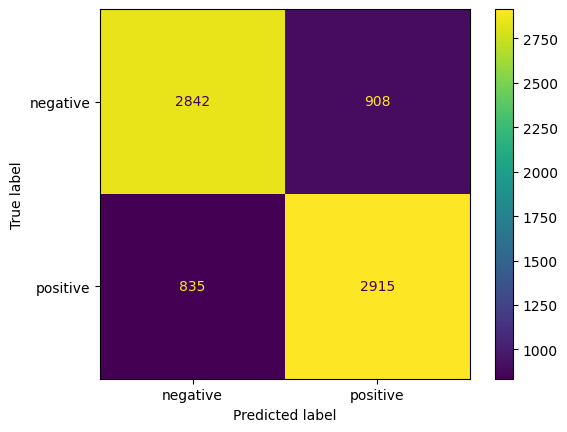

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, target_names=["negative","positive"], digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative","positive"])
disp.plot()
plt.show()


## 10) Loss curves

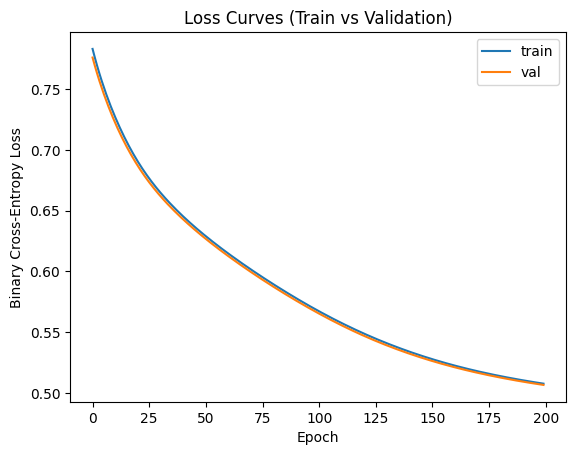

In [14]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curves (Train vs Validation)")
plt.legend()
plt.show()


## 11) Save artifacts (model, metrics, PNGs, discussion, submission.csv)

In [ ]:
import os, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

OUT_DIR = os.path.abspath("..")
os.makedirs(os.path.join(OUT_DIR, "model"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "results"), exist_ok=True)

# Save best model (weights/biases) to PKL
model_path = os.path.join(OUT_DIR, "model", "best_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump({
        "params": best_params,
        "hidden_dim": HIDDEN_DIM,
        "lr": LR,
        "epochs": EPOCHS,
        "l2": L2,
        "feature": "TextBlob polarity (sentence-level, 1 feature)"
    }, f)

# Save metrics.txt
metrics_path = os.path.join(OUT_DIR, "results", "metrics.txt")
with open(metrics_path, "w", encoding="utf-8") as f:
    f.write(f"Test accuracy: {acc:.4f}\n\n")
    f.write("Classification report:\n")
    f.write(classification_report(y_test, y_pred, target_names=["negative","positive"], digits=4))
    f.write("\nConfusion matrix (rows=true, cols=pred):\n")
    f.write(np.array2string(cm))

# Save confusion matrix figure
cm_path = os.path.join(OUT_DIR, "results", "confusion_matrix.png")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative","positive"])
disp.plot()
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.close()

# Save loss curves figure
loss_path = os.path.join(OUT_DIR, "results", "loss_curves.png")
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curves (Train vs Validation)")
plt.legend()
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.close()

# Save brief discussion
discussion_path = os.path.join(OUT_DIR, "results", "results_discussion.txt")
with open(discussion_path, "w", encoding="utf-8") as f:
    f.write(
        "Results Discussion\n"
        "- Features: TextBlob sentence-level polarity only (1D feature).\n"
        "- Model: MLP trained from scratch with manual forward pass, backprop, and gradient descent.\n"
        "- Strengths: Works when reviews have clearly positive/negative polarity.\n"
        "- Errors: Sarcasm and mixed reviews are hard when using only one polarity feature.\n"
        "- Improvement (if allowed): Hybrid (VADER + TextBlob polarity) or more features (not allowed here).\n"
    )

# Save submission.csv (predictions on the held-out test split)
submission_path = os.path.join(OUT_DIR, "submission.csv")
submission_df = pd.DataFrame({
    "id": np.arange(len(y_pred)),
    "sentiment_pred": np.where(y_pred == 1, "positive", "negative"),
    "prob_positive": test_probs.flatten()
})
submission_df.to_csv(submission_path, index=False)

print("Saved:")
print(" -", model_path)
print(" -", metrics_path)
print(" -", cm_path)
print(" -", loss_path)
print(" -", discussion_path)
print(" -", submission_path)
submission_df.head()
